<a href="https://colab.research.google.com/github/22wh1a04c6/Data-Science-Task/blob/main/LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Logistic Regression

#Cancer Prediction

In [31]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.datasets import load_breast_cancer

In [32]:
#Data preparation
data=load_breast_cancer()
data.keys()
df=pd.DataFrame(data['data'],columns=data['feature_names'])
df["cancer"]=data["target"]
df["cancer"].unique()

array([0, 1])

<Axes: xlabel='cancer', ylabel='Count'>

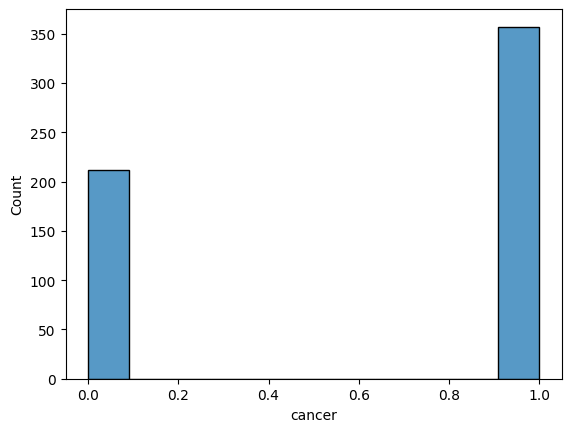

In [33]:
sns.histplot(x="cancer",data=df)

<Axes: xlabel='mean radius', ylabel='Count'>

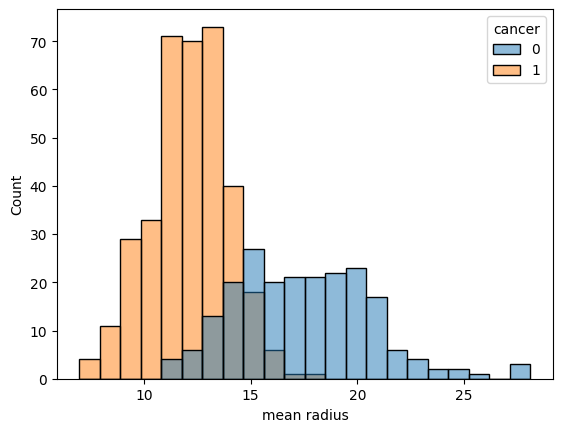

In [34]:
sns.histplot(x="mean radius",data=df,hue="cancer")

# Model Training

In [35]:
#divide data into input and output
x=df.drop("cancer",axis=1)
y=df["cancer"]

In [36]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=42)

In [37]:
#logistic regression
model=LogisticRegression()
model.fit(xtrain,ytrain)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [38]:
ypred=model.predict(xtest)

In [39]:
confusion_matrix(ytest,ypred)

array([[ 59,   4],
       [  1, 107]])

In [40]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.98      0.94      0.96        63
           1       0.96      0.99      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



In [41]:
print("Training eff:",model.score(xtrain,ytrain))
print("Testing eff:",model.score(xtest,ytest))

Training eff: 0.9346733668341709
Testing eff: 0.9707602339181286


In [42]:
# new input
new_data=df.iloc[:1,:-1]
pred=model.predict(new_data)
prob=model.predict_proba(new_data)
if pred[0]==0:
  print("no cancer")
else:
  print("cancer is there")
print("Probability:",prob) #first one is not having cancer probability and next is having cancer probability

no cancer
Probability: [[1.00000000e+00 5.82333545e-14]]


In [43]:
df.iloc[[568],:-1]


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.0,0.0,0.1587,0.05884,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0,0.0,0.2871,0.07039


#Heart disease prediction


In [44]:
df=pd.read_csv("heart.csv")
df

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [46]:
df.drop("Unnamed: 0",axis=1)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [ ]:
df.isnull().sum()

([<matplotlib.patches.Wedge at 0x7a866db35430>,
 [Text(-0.15346694397759053, 1.0892418909985877, 'male'),
  Text(0.15346716904989344, -1.0892418592873723, 'female')],
 [Text(-0.08370924216959483, 0.5941319405446842, '54.46%'),
  Text(0.0837093649363055, -0.5941319232476575, '45.54%')])

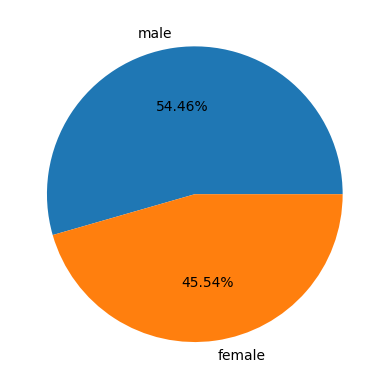

In [55]:
#pie chart for sex and target
df.target.value_counts()
plt.pie(df.target.value_counts(),labels=["male","female"],autopct="%0.2f%%")

<Axes: xlabel='age', ylabel='Count'>

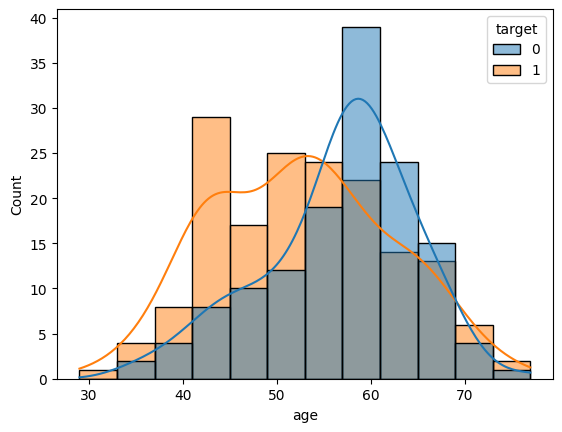

In [60]:
sns.histplot(x="age",data=df,hue="target",kde=True)

<Axes: xlabel='trestbps', ylabel='Count'>

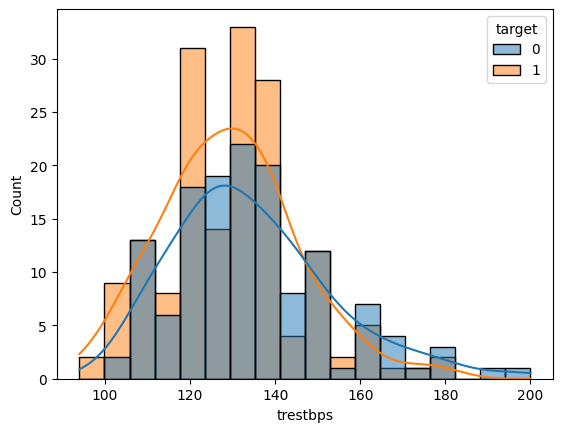

In [56]:
sns.histplot(x="trestbps",data=df,hue="target",kde=True)

#Model Training

In [57]:
x=df.drop("target",axis=1)
y=df["target"]

In [58]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=42)

In [59]:
#logistic regression
model=LogisticRegression()
model.fit(xtrain,ytrain)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [61]:
ypred=model.predict(xtest)

In [62]:
confusion_matrix(ytest,ypred)

array([[40,  1],
       [ 1, 49]])

In [63]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        41
           1       0.98      0.98      0.98        50

    accuracy                           0.98        91
   macro avg       0.98      0.98      0.98        91
weighted avg       0.98      0.98      0.98        91



In [64]:
print("training eff:",model.score(xtrain,ytrain))
print("testing eff:",model.score(xtest,ytest))

training eff: 1.0
testing eff: 0.978021978021978


In [66]:
# new input
new_data=df.iloc[:1,:-1]
pred=model.predict(new_data)
prob=model.predict_proba(new_data)
if pred[0]==0:
  print("no heart disease")
else:
  print("heart disease is there")
print("Probability:",prob)

heart disease is there
Probability: [[0. 1.]]
